# 🌱 Simulation of Wheat Vegetative Growth with the WheatFSPM

### Authors : R. Barillot, C.Chambon, M.Gauthier & B. Andrieu
### Publication : https://doi.org/10.1093/jxb/eraa276

[WheatFspm](https://wheatfspm.readthedocs.io/en/latest/?badge=latest) is a Functional Structural Plant Model (FSPM) of wheat which fully integrates shoot morphogenesis and the metabolism of carbon (C) and nitrogen (N) at organ scale within a 3D representation of plant architecture. Plants are described as a collection of tillers, each consisting in individual shoot organs (lamina, sheath, internode, peduncle, chaff), a single root compartment, the grains, and a phloem.

This tutorial will illustrate how to use the WheatFspm model to simulate the growth and functioning of a wheat plant during the vegetative stages. The tutorial is based on the script [main.py](https://github.com/openalea/WheatFspm/blob/master/example/Vegetative_stages/main.py).

## 🛠️ Configuration and prerequisites
Let's import all the required packages

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Adel-Wheat dependencies (https://github.com/openalea/adel)
from openalea.adel.adel_dynamic import AdelDyn
from openalea.adel.echap_leaf import echap_leaves

from openalea.fspmwheat import caribu_facade
from openalea.fspmwheat import cnwheat_facade
from openalea.fspmwheat import elongwheat_facade
from openalea.fspmwheat import farquharwheat_facade
from openalea.fspmwheat import fspmwheat_facade
from openalea.fspmwheat import growthwheat_facade
from openalea.fspmwheat import senescwheat_facade


## Model inputs
* Weather data
They should contain the following variables :
    * *t*: the time index used in the simulation (hour)
    * *DOY*: the Day Of the Year
    * *hour*: the hour of the day [1-24]
    * *air_temperature*: temperature of the air (°C)
    * *soil_temperature*: temperature of the soil (°C)
    * *PARi*: incident Photosynthetically Active Radiation above the canopy (µmol m-2 s-1)
    * *humidity*: air humidity (relative)
    * *ambient_CO2*: CO2 concentration of the atmosphere (ppm)
    * *Wind* : wind speed 2m above the canopy (m s-1)


In [3]:
# Loading a meteo file and display head
METEO_FILENAME = r'inputs\meteo_file.csv'
meteo = pd.read_csv(METEO_FILENAME, delimiter=',',  index_col='t')
meteo.head()

,DOY,hour,air_temperature,PARi,soil_temperature,humidity,ambient_CO2,Wind
t,,,,,,,,
0,351,12,5.2,516.222222,5.840,0.95,360,2.9
1,351,13,5.6,549.888889,6.264,0.88,360,2.9
2,351,14,4.8,392.777778,5.415,0.92,360,2.9
3,351,15,3.6,157.111111,6.223,0.95,360,2.9
4,351,16,3.5,22.444444,5.957,0.96,360,2.9


* Setting management

In [4]:
PLANT_DENSITY = {1: 250}  # Number of plants per square meter (value) for each genotype (key)
tillers_replications = {'T1': 0.5, 'T2': 0.5, 'T3': 0.5, 'T4': 0.5}  # In the current version, tillering is a model input (tiller id as key, and weight of replication as value)
N_fertilizations = {1440: 357143, 2520: 1000000}  # Date of N fertilisation (key ; hour of the simulation) anf N amounts (µmol of N). Note: you can also use {'constant_Conc_Nitrates': val} for constant nitrate concentrations.
SIMULATION_LENGTH = 48  # length of the simulation (hours)
START_TIME = 0

# precision of floats used to write and format the output CSV files
OUTPUTS_PRECISION = 2

# Rates and time-dependant parameters in WheatFspm are expressed in s or s-1 but simulations (and differential equations solve) are usually integrated over an hour
HOUR_TO_SECOND_CONVERSION_FACTOR = 3600

* Initial conditions
The initial state of the different plant organs and the soil are loaded from different csv files. They mainly contain the initial dimensions, masses and metabolic contents.

In [5]:
# Name of the CSV files which describes the initial state of the system
AXES_INITIAL_STATE_FILENAME = 'axes_initial_state.csv'  # Axis scale
ORGANS_INITIAL_STATE_FILENAME = 'organs_initial_state.csv'  # Organ scale (contains data for the roots and phloem compartments)
HIDDENZONES_INITIAL_STATE_FILENAME = 'hiddenzones_initial_state.csv'  # Hidden zone scale
ELEMENTS_INITIAL_STATE_FILENAME = 'elements_initial_state.csv'  # Photosynthetic element scale
SOILS_INITIAL_STATE_FILENAME = 'soils_initial_state.csv'  # Soil

# Read the inputs from CSV files and create inputs dataframes
inputs_dataframes = {}
for inputs_filename in (AXES_INITIAL_STATE_FILENAME,
                        ORGANS_INITIAL_STATE_FILENAME,
                        HIDDENZONES_INITIAL_STATE_FILENAME,
                        ELEMENTS_INITIAL_STATE_FILENAME,
                        SOILS_INITIAL_STATE_FILENAME):
    inputs_dataframe = pd.read_csv(os.path.join('inputs', inputs_filename))
    inputs_dataframes[inputs_filename] = inputs_dataframe.where(inputs_dataframe.notnull(), None)
# Example of the inputs provided for the elements
inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].head()

,plant,axis,metamer,organ,element,age,length,Wmax,is_growing,mstruct,...,starch,nitrates,senesced_length_element,Nresidual,max_mstruct,is_over,Ag,Tr,Ts,triosesP
0,1,MS,1,blade,LeafElement1,240,0.0820,0.0030,False,0.004107,...,0,0,0,0,0.004107,False,0,0,20,0
1,1,MS,1,sheath,StemElement,240,0.0285,NaN,False,0.001710,...,0,0,0,0,0.001710,False,0,0,20,0
2,1,MS,2,blade,LeafElement1,160,0.0920,0.0033,False,0.004838,...,0,0,0,0,0.004838,False,0,0,20,0
3,1,MS,2,sheath,HiddenElement,160,0.0285,NaN,False,0.002280,...,0,0,0,0,0.002280,False,0,0,20,0
4,1,MS,2,sheath,StemElement,160,0.0005,NaN,False,0.000040,...,0,0,0,0,0.000040,False,0,0,20,0


Note the decomposition of the plant into axes, metamers, organs and elements. More information can be found in the [documentation](https://wheatfspm.readthedocs.io/en/latest/?badge=latest).

* Configuration of Adel-Wheat
WheatFspm includes an implicit coupling to the model [Adel-Wheat](https://adel.readthedocs.io/en/latest/?badge=latest). This models allows for the 3D representation of the wheat architecture and the generation of the MTG object used for the communication (read/write) between each submodule of WheatFspm. In this example, we will use the leaf database for the wheat cultivar Soissons.

In [6]:
# Instantiates AdelDyn object with Soissons database and set scene unit to meter
adel_wheat = AdelDyn(seed=1, scene_unit='m', leaves=echap_leaves(xy_model='Soissons_byleafclass'))
# Instantiates a MTG object from a pickle
g = adel_wheat.load(directory='inputs')

* Configuration of outputs and postprocessings

In [7]:
# -- OUTPUT CONFIGURATION --
OUTPUTS_DIRPATH = os.path.join('outputs', 'simple_run_vegetative_stages')

# Name of the CSV files which will contain the outputs of the model
AXES_OUTPUTS_FILENAME = 'axes_outputs.csv'
ORGANS_OUTPUTS_FILENAME = 'organs_outputs.csv'
HIDDENZONES_OUTPUTS_FILENAME = 'hiddenzones_outputs.csv'
ELEMENTS_OUTPUTS_FILENAME = 'elements_outputs.csv'
SOILS_OUTPUTS_FILENAME = 'soils_outputs.csv'

# create empty dataframes to shared data between the models
shared_axes_inputs_outputs_df = pd.DataFrame()
shared_organs_inputs_outputs_df = pd.DataFrame()
shared_hiddenzones_inputs_outputs_df = pd.DataFrame()
shared_elements_inputs_outputs_df = pd.DataFrame()
shared_soils_inputs_outputs_df = pd.DataFrame()

# define lists of dataframes to store the inputs and the outputs of the models at each step.
axes_all_data_list = []
organs_all_data_list = []  # organs which belong to axes: roots, phloem, grains
hiddenzones_all_data_list = []
elements_all_data_list = []
soils_all_data_list = []

all_simulation_steps = []  # to store the steps of the simulation

# -- POSTPROCESSING CONFIGURATION --
POSTPROCESSING_DIRPATH= os.path.join('postprocessing', 'simple_run_vegetative_stages')

# Name of the CSV files which will contain the postprocessing of the model
AXES_POSTPROCESSING_FILENAME = 'axes_postprocessing.csv'
ORGANS_POSTPROCESSING_FILENAME = 'organs_postprocessing.csv'
HIDDENZONES_POSTPROCESSING_FILENAME = 'hiddenzones_postprocessing.csv'
ELEMENTS_POSTPROCESSING_FILENAME = 'elements_postprocessing.csv'
SOILS_POSTPROCESSING_FILENAME = 'soils_postprocessing.csv'

* Configuration of the facades
WheatFspm is structured in several submodules. Each has a 'facade' which allows to (i) read the inputs necessary for the submodule from the MTG and (ii) write the outputs after the submodule run into the MTG. The followwing steps are required for the configuration of each facade.

In [8]:
# define the time step in hours for each submodule
CARIBU_TIMESTEP = 4
SENESCWHEAT_TIMESTEP = 1
FARQUHARWHEAT_TIMESTEP = 1
ELONGWHEAT_TIMESTEP = 1
GROWTHWHEAT_TIMESTEP = 1
CNWHEAT_TIMESTEP = 1


# -- CARIBU -- The light distribution model
caribu_facade_ = caribu_facade.CaribuFacade(g,
                                            shared_elements_inputs_outputs_df,
                                            adel_wheat,
                                            update_shared_df=False)

# -- ELONGWHEAT -- The submodule dealing with elongation
# Initial states
elongwheat_hiddenzones_initial_state = inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME][
    elongwheat_facade.converter.HIDDENZONE_TOPOLOGY_COLUMNS + [i for i in elongwheat_facade.simulation.HIDDENZONE_INPUTS if i in
                                                               inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME].columns]].copy()
elongwheat_elements_initial_state = inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME][
    elongwheat_facade.converter.ELEMENT_TOPOLOGY_COLUMNS + [i for i in elongwheat_facade.simulation.ELEMENT_INPUTS if i in
                                                            inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].columns]].copy()
elongwheat_axes_initial_state = inputs_dataframes[AXES_INITIAL_STATE_FILENAME][
    elongwheat_facade.converter.AXIS_TOPOLOGY_COLUMNS + [i for i in elongwheat_facade.simulation.AXIS_INPUTS if i in inputs_dataframes[AXES_INITIAL_STATE_FILENAME].columns]].copy()

phytoT_df = pd.read_csv(os.path.join('inputs', 'phytoT.csv'))

# Facade initialisation
elongwheat_facade_ = elongwheat_facade.ElongWheatFacade(g,
                                                        ELONGWHEAT_TIMESTEP * HOUR_TO_SECOND_CONVERSION_FACTOR,
                                                        elongwheat_axes_initial_state,
                                                        elongwheat_hiddenzones_initial_state,
                                                        elongwheat_elements_initial_state,
                                                        shared_axes_inputs_outputs_df,
                                                        shared_hiddenzones_inputs_outputs_df,
                                                        shared_elements_inputs_outputs_df,
                                                        adel_wheat, phytoT_df,
                                                        update_shared_df=False)

# -- SENESCWHEAT -- The submodule dealing with leaf and root senescence
# Initial states
senescwheat_roots_initial_state = inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME].loc[inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME]['organ'] == 'roots'][
    senescwheat_facade.converter.ROOTS_TOPOLOGY_COLUMNS +
    [i for i in senescwheat_facade.converter.SENESCWHEAT_ROOTS_INPUTS if i in inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME].columns]].copy()

senescwheat_elements_initial_state = inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME][
    senescwheat_facade.converter.ELEMENTS_TOPOLOGY_COLUMNS +
    [i for i in senescwheat_facade.converter.SENESCWHEAT_ELEMENTS_INPUTS if i in inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].columns]].copy()

senescwheat_axes_initial_state = inputs_dataframes[AXES_INITIAL_STATE_FILENAME][
    senescwheat_facade.converter.AXES_TOPOLOGY_COLUMNS +
    [i for i in senescwheat_facade.converter.SENESCWHEAT_AXES_INPUTS if i in inputs_dataframes[AXES_INITIAL_STATE_FILENAME].columns]].copy()

# Facade initialisation
senescwheat_facade_ = senescwheat_facade.SenescWheatFacade(g,
                                                           SENESCWHEAT_TIMESTEP * HOUR_TO_SECOND_CONVERSION_FACTOR,
                                                           senescwheat_roots_initial_state,
                                                           senescwheat_axes_initial_state,
                                                           senescwheat_elements_initial_state,
                                                           shared_organs_inputs_outputs_df,
                                                           shared_axes_inputs_outputs_df,
                                                           shared_elements_inputs_outputs_df,
                                                           update_shared_df=False)

# -- FARQUHARWHEAT -- The submodule dealing with leaf photosynthesis, transpiration and temperature
# Initial states
farquharwheat_elements_initial_state = inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME][
    farquharwheat_facade.converter.ELEMENT_TOPOLOGY_COLUMNS +
    [i for i in farquharwheat_facade.converter.FARQUHARWHEAT_ELEMENTS_INPUTS if i in inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].columns]].copy()

farquharwheat_axes_initial_state = inputs_dataframes[AXES_INITIAL_STATE_FILENAME][
    farquharwheat_facade.converter.AXIS_TOPOLOGY_COLUMNS +
    [i for i in farquharwheat_facade.converter.FARQUHARWHEAT_AXES_INPUTS if i in inputs_dataframes[AXES_INITIAL_STATE_FILENAME].columns]].copy()

# Use the initial version of the photosynthesis sub-model (as in Barillot et al. 2016, and in Gauthier et al. 2020)
update_parameters_farquharwheat = {'SurfacicProteins': False, 'NSC_Retroinhibition': False}

# Facade initialisation
farquharwheat_facade_ = farquharwheat_facade.FarquharWheatFacade(g,
                                                                 farquharwheat_elements_initial_state,
                                                                 farquharwheat_axes_initial_state,
                                                                 shared_elements_inputs_outputs_df,
                                                                 update_parameters_farquharwheat,
                                                                 update_shared_df=False)

# -- GROWTHWHEAT -- The submodule dealing with leaf and root growth
# Initial states
growthwheat_hiddenzones_initial_state = inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME][
    growthwheat_facade.converter.HIDDENZONE_TOPOLOGY_COLUMNS +
    [i for i in growthwheat_facade.simulation.HIDDENZONE_INPUTS if i in inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME].columns]].copy()

growthwheat_elements_initial_state = inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME][
    growthwheat_facade.converter.ELEMENT_TOPOLOGY_COLUMNS +
    [i for i in growthwheat_facade.simulation.ELEMENT_INPUTS if i in inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].columns]].copy()

growthwheat_root_initial_state = inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME].loc[inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME]['organ'] == 'roots'][
    growthwheat_facade.converter.ROOT_TOPOLOGY_COLUMNS +
    [i for i in growthwheat_facade.simulation.ROOT_INPUTS if i in inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME].columns]].copy()

growthwheat_axes_initial_state = inputs_dataframes[AXES_INITIAL_STATE_FILENAME][
    growthwheat_facade.converter.AXIS_TOPOLOGY_COLUMNS +
    [i for i in growthwheat_facade.simulation.AXIS_INPUTS if i in inputs_dataframes[AXES_INITIAL_STATE_FILENAME].columns]].copy()

# Facade initialisation
growthwheat_facade_ = growthwheat_facade.GrowthWheatFacade(g,
                                                           GROWTHWHEAT_TIMESTEP * HOUR_TO_SECOND_CONVERSION_FACTOR,
                                                           growthwheat_hiddenzones_initial_state,
                                                           growthwheat_elements_initial_state,
                                                           growthwheat_root_initial_state,
                                                           growthwheat_axes_initial_state,
                                                           shared_organs_inputs_outputs_df,
                                                           shared_hiddenzones_inputs_outputs_df,
                                                           shared_elements_inputs_outputs_df,
                                                           shared_axes_inputs_outputs_df,
                                                           update_shared_df=False)

# -- CNWHEAT -- The submodule dealing with C-N metabolism (embedding a differential equation solver)
# Initial states
cnwheat_organs_initial_state = inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME][
    [i for i in cnwheat_facade.cnwheat_converter.ORGANS_VARIABLES if i in inputs_dataframes[ORGANS_INITIAL_STATE_FILENAME].columns]].copy()

cnwheat_hiddenzones_initial_state = inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME][
    [i for i in cnwheat_facade.cnwheat_converter.HIDDENZONE_VARIABLES if i in inputs_dataframes[HIDDENZONES_INITIAL_STATE_FILENAME].columns]].copy()

cnwheat_elements_initial_state = inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME][
    [i for i in cnwheat_facade.cnwheat_converter.ELEMENTS_VARIABLES if i in inputs_dataframes[ELEMENTS_INITIAL_STATE_FILENAME].columns]].copy()

cnwheat_soils_initial_state = inputs_dataframes[SOILS_INITIAL_STATE_FILENAME][
    [i for i in cnwheat_facade.cnwheat_converter.SOILS_VARIABLES if i in inputs_dataframes[SOILS_INITIAL_STATE_FILENAME].columns]].copy()


# Facade initialisation
cnwheat_facade_ = cnwheat_facade.CNWheatFacade(g,
                                               CNWHEAT_TIMESTEP * HOUR_TO_SECOND_CONVERSION_FACTOR,
                                               PLANT_DENSITY,
                                               {},
                                               cnwheat_organs_initial_state,
                                               cnwheat_hiddenzones_initial_state,
                                               cnwheat_elements_initial_state,
                                               cnwheat_soils_initial_state,
                                               shared_axes_inputs_outputs_df,
                                               shared_organs_inputs_outputs_df,
                                               shared_hiddenzones_inputs_outputs_df,
                                               shared_elements_inputs_outputs_df,
                                               shared_soils_inputs_outputs_df,
                                               update_shared_df=False)

# -- FSPMWHEAT --
# Facade initialisation
fspmwheat_facade_ = fspmwheat_facade.FSPMWheatFacade(g)
# g.display()

# Update geometry
adel_wheat.update_geometry(g)
# adel_wheat.plot(g)

## Run of the simulation
Running the simulation consists in nested loops where each facade is executed sequentially.

In [9]:
for t_caribu in range(START_TIME, SIMULATION_LENGTH, SENESCWHEAT_TIMESTEP):
    # run Caribu
    PARi = meteo.loc[t_caribu, ['PARi']].iloc[0]
    DOY = meteo.loc[t_caribu, ['DOY']].iloc[0]
    hour = meteo.loc[t_caribu, ['hour']].iloc[0]
    PARi_next_hours = meteo.loc[range(t_caribu, t_caribu + CARIBU_TIMESTEP), ['PARi']].sum().values[0]

    if (t_caribu % CARIBU_TIMESTEP == 0) and (PARi_next_hours > 0):
        run_caribu = True
    else:
        run_caribu = False

    # Specify here the latitude of your site and the type of scene illumination for Caribu configuration
    caribu_facade_.run(run_caribu, energy=PARi, DOY=DOY, hourTU=hour, latitude=48.85, sun_sky_option='sky', heterogeneous_canopy=False, plant_density=PLANT_DENSITY[1])

    for t_senescwheat in range(t_caribu, t_caribu + SENESCWHEAT_TIMESTEP, SENESCWHEAT_TIMESTEP):
        # run SenescWheat
        senescwheat_facade_.run()

        # Test for dead plant # TODO: adapt in case of multiple plants
        if not shared_elements_inputs_outputs_df.empty and \
                np.nansum(shared_elements_inputs_outputs_df.loc[shared_elements_inputs_outputs_df['element'].isin(['StemElement', 'LeafElement1']), 'green_area']) == 0:
            # append the inputs and outputs at current step to global lists
            all_simulation_steps.append(t_senescwheat)
            axes_all_data_list.append(shared_axes_inputs_outputs_df.copy())
            organs_all_data_list.append(shared_organs_inputs_outputs_df.copy())
            hiddenzones_all_data_list.append(shared_hiddenzones_inputs_outputs_df.copy())
            elements_all_data_list.append(shared_elements_inputs_outputs_df.copy())
            soils_all_data_list.append(shared_soils_inputs_outputs_df.copy())
            break

        # Run the rest of the model if the plant is alive
        for t_farquharwheat in range(t_senescwheat, t_senescwheat + SENESCWHEAT_TIMESTEP, FARQUHARWHEAT_TIMESTEP):
            # get the meteo of the current step
            Ta, ambient_CO2, RH, Ur = meteo.loc[t_farquharwheat, ['air_temperature', 'ambient_CO2', 'humidity', 'Wind']]

            # run FarquharWheat
            farquharwheat_facade_.run(Ta, ambient_CO2, RH, Ur)

            for t_elongwheat in range(t_farquharwheat, t_farquharwheat + FARQUHARWHEAT_TIMESTEP, ELONGWHEAT_TIMESTEP):
                # run ElongWheat
                Tair, Tsoil = meteo.loc[t_elongwheat, ['air_temperature', 'soil_temperature']]
                elongwheat_facade_.run(Tair, Tsoil)

                # Update geometry
                adel_wheat.update_geometry(g)

                for t_growthwheat in range(t_elongwheat, t_elongwheat + ELONGWHEAT_TIMESTEP, GROWTHWHEAT_TIMESTEP):
                    # run GrowthWheat
                    growthwheat_facade_.run()

                    for t_cnwheat in range(t_growthwheat, t_growthwheat + GROWTHWHEAT_TIMESTEP, CNWHEAT_TIMESTEP):
                        print('t cnwheat is {}'.format(t_cnwheat))

                        # N fertilization if any
                        if N_fertilizations is not None and len(N_fertilizations) > 0:
                            if t_cnwheat in N_fertilizations.keys():
                                cnwheat_facade_.soils[(1, 'MS')].nitrates += N_fertilizations[t_cnwheat]

                        if t_cnwheat > 0:
                            # run CNWheat
                            Tair = meteo.loc[t_elongwheat, 'air_temperature']
                            Tsoil = meteo.loc[t_elongwheat, 'soil_temperature']
                            cnwheat_facade_.run(Tair, Tsoil, tillers_replications)

                        # append outputs at current step to global lists
                        axes_outputs, elements_outputs, hiddenzones_outputs, organs_outputs, soils_outputs = fspmwheat_facade_.build_outputs_df_from_MTG()

                        all_simulation_steps.append(t_cnwheat)
                        axes_all_data_list.append(axes_outputs)
                        organs_all_data_list.append(organs_outputs)
                        hiddenzones_all_data_list.append(hiddenzones_outputs)
                        elements_all_data_list.append(elements_outputs)
                        soils_all_data_list.append(soils_outputs)


t cnwheat is 0
t cnwheat is 1
t cnwheat is 2
t cnwheat is 3
t cnwheat is 4
t cnwheat is 5
t cnwheat is 6
t cnwheat is 7
t cnwheat is 8
t cnwheat is 9
t cnwheat is 10
t cnwheat is 11
t cnwheat is 12
t cnwheat is 13
t cnwheat is 14
t cnwheat is 15
t cnwheat is 16
t cnwheat is 17
t cnwheat is 18
t cnwheat is 19
t cnwheat is 20
t cnwheat is 21
t cnwheat is 22
t cnwheat is 23
t cnwheat is 24
t cnwheat is 25
t cnwheat is 26
t cnwheat is 27
t cnwheat is 28
t cnwheat is 29
t cnwheat is 30
t cnwheat is 31
t cnwheat is 32
t cnwheat is 33
t cnwheat is 34
t cnwheat is 35
t cnwheat is 36
t cnwheat is 37
t cnwheat is 38
t cnwheat is 39
t cnwheat is 40
t cnwheat is 41
t cnwheat is 42
t cnwheat is 43
t cnwheat is 44
t cnwheat is 45
t cnwheat is 46
t cnwheat is 47


## Generate outputs and postprocessing
Outputs relate to the different variable solved by the model, while the postprocessing include extra-calculations allowing for in-depth interpretation of the simulations. Outputs and postprocessing are written as csv files, one per scale (axis, organs, hiddenzones, elements and soil). Files are stored in /outputs/simple_run_vegetative_stages and /postprocessing/simple_run_vegetative_stages

In [12]:
## -- OUTPUTS

AXES_INDEX_COLUMNS = ['t', 'plant', 'axis']
ELEMENTS_INDEX_COLUMNS = ['t', 'plant', 'axis', 'metamer', 'organ', 'element']
HIDDENZONES_INDEX_COLUMNS = ['t', 'plant', 'axis', 'metamer']
ORGANS_INDEX_COLUMNS = ['t', 'plant', 'axis', 'organ']
SOILS_INDEX_COLUMNS = ['t', 'plant', 'axis']

# convert list of outputs into dataframes
outputs_df_dict = {}
for outputs_df_list, outputs_filename, index_columns in ((axes_all_data_list, AXES_OUTPUTS_FILENAME, AXES_INDEX_COLUMNS),
                                                         (organs_all_data_list, ORGANS_OUTPUTS_FILENAME, ORGANS_INDEX_COLUMNS),
                                                         (hiddenzones_all_data_list, HIDDENZONES_OUTPUTS_FILENAME, HIDDENZONES_INDEX_COLUMNS),
                                                         (elements_all_data_list, ELEMENTS_OUTPUTS_FILENAME, ELEMENTS_INDEX_COLUMNS),
                                                         (soils_all_data_list, SOILS_OUTPUTS_FILENAME, SOILS_INDEX_COLUMNS)):
    outputs_filepath = os.path.join(OUTPUTS_DIRPATH, outputs_filename)
    outputs_df = pd.concat(outputs_df_list, keys=all_simulation_steps, sort=False)
    outputs_df.reset_index(0, inplace=True)
    outputs_df.rename({'level_0': 't'}, axis=1, inplace=True)
    outputs_df = outputs_df.reindex(index_columns + outputs_df.columns.difference(index_columns).tolist(), axis=1, copy=False)
    outputs_df.fillna(value=np.nan, inplace=True)  # Convert back None to NaN
    outputs_df.to_csv(outputs_filepath, na_rep='NA', index=False, float_format='%.{}f'.format(OUTPUTS_PRECISION))
    outputs_file_basename = outputs_filename.split('.')[0]
    outputs_df_dict[outputs_file_basename] = outputs_df.reset_index()

## -- POSTPROCESSING
delta_t = CNWHEAT_TIMESTEP * HOUR_TO_SECOND_CONVERSION_FACTOR

# run the postprocessing
axes_postprocessing_file_basename = AXES_POSTPROCESSING_FILENAME.split('.')[0]
hiddenzones_postprocessing_file_basename = HIDDENZONES_POSTPROCESSING_FILENAME.split('.')[0]
organs_postprocessing_file_basename = ORGANS_POSTPROCESSING_FILENAME.split('.')[0]
elements_postprocessing_file_basename = ELEMENTS_POSTPROCESSING_FILENAME.split('.')[0]
soils_postprocessing_file_basename = SOILS_POSTPROCESSING_FILENAME.split('.')[0]

postprocessing_df_dict = {}
(postprocessing_df_dict[axes_postprocessing_file_basename],
 postprocessing_df_dict[hiddenzones_postprocessing_file_basename],
 postprocessing_df_dict[organs_postprocessing_file_basename],
 postprocessing_df_dict[elements_postprocessing_file_basename],
 postprocessing_df_dict[soils_postprocessing_file_basename]) \
    = cnwheat_facade.CNWheatFacade.postprocessing(axes_outputs_df=outputs_df_dict[AXES_OUTPUTS_FILENAME.split('.')[0]],
                                                  hiddenzone_outputs_df=outputs_df_dict[HIDDENZONES_OUTPUTS_FILENAME.split('.')[0]],
                                                  organs_outputs_df=outputs_df_dict[ORGANS_OUTPUTS_FILENAME.split('.')[0]],
                                                  elements_outputs_df=outputs_df_dict[ELEMENTS_OUTPUTS_FILENAME.split('.')[0]],
                                                  soils_outputs_df=outputs_df_dict[SOILS_OUTPUTS_FILENAME.split('.')[0]],
                                                  delta_t=delta_t)

for postprocessing_file_basename, postprocessing_filename in ((axes_postprocessing_file_basename, AXES_POSTPROCESSING_FILENAME),
                                                              (hiddenzones_postprocessing_file_basename, HIDDENZONES_POSTPROCESSING_FILENAME),
                                                              (organs_postprocessing_file_basename, ORGANS_POSTPROCESSING_FILENAME),
                                                              (elements_postprocessing_file_basename, ELEMENTS_POSTPROCESSING_FILENAME),
                                                              (soils_postprocessing_file_basename, SOILS_POSTPROCESSING_FILENAME)):
    postprocessing_filepath = os.path.join(POSTPROCESSING_DIRPATH, postprocessing_filename)
    postprocessing_df_dict[postprocessing_file_basename].to_csv(postprocessing_filepath, na_rep='NA', index=False, float_format='%.{}f'.format(OUTPUTS_PRECISION))


## Generate graphs
Graphs are stored in the folder /graphs/simple_run_vegetative_stages

In [13]:
GRAPHS_DIRPATH = os.path.join('graphs', 'simple_run_vegetative_stages')
# Retrieve last computed post-processing dataframes
axes_postprocessing_file_basename = AXES_POSTPROCESSING_FILENAME.split('.')[0]
organs_postprocessing_file_basename = ORGANS_POSTPROCESSING_FILENAME.split('.')[0]
hiddenzones_postprocessing_file_basename = HIDDENZONES_POSTPROCESSING_FILENAME.split('.')[0]
elements_postprocessing_file_basename = ELEMENTS_POSTPROCESSING_FILENAME.split('.')[0]
soils_postprocessing_file_basename = SOILS_POSTPROCESSING_FILENAME.split('.')[0]

# --- Generate graphs from postprocessing files
plt.ioff()

cnwheat_facade.CNWheatFacade.graphs(axes_postprocessing_df=postprocessing_df_dict[axes_postprocessing_file_basename],
                                    hiddenzones_postprocessing_df=postprocessing_df_dict[hiddenzones_postprocessing_file_basename],
                                    organs_postprocessing_df=postprocessing_df_dict[organs_postprocessing_file_basename],
                                    elements_postprocessing_df=postprocessing_df_dict[elements_postprocessing_file_basename],
                                    soils_postprocessing_df=postprocessing_df_dict[soils_postprocessing_file_basename],
                                    graphs_dirpath=GRAPHS_DIRPATH)

## 📈 Key Results Visualization

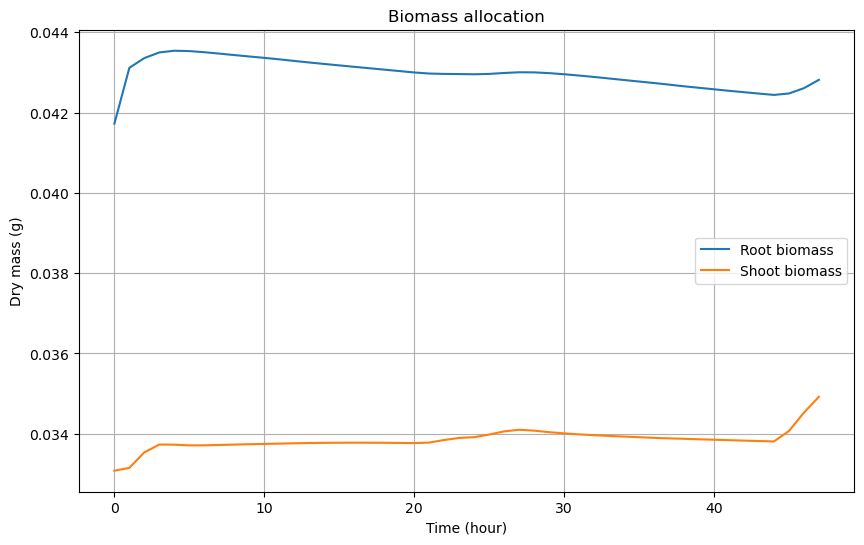

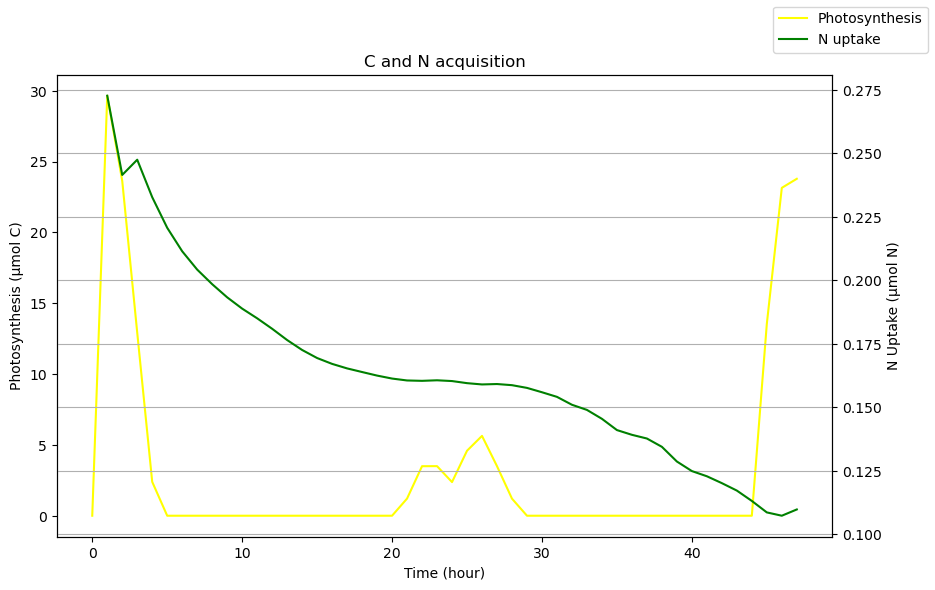

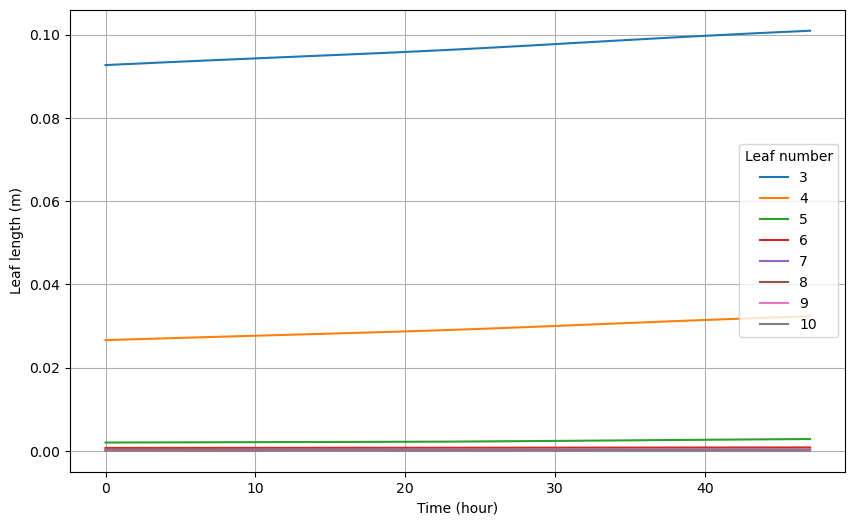

In [37]:
axes_postprocessing_df = postprocessing_df_dict['axes_postprocessing']
roots_postprocessing_df = postprocessing_df_dict['organs_postprocessing'][postprocessing_df_dict['organs_postprocessing']['organ'] == 'roots']
hz_postprocessing_df = postprocessing_df_dict['hiddenzones_postprocessing']

# Biomass allocation
plt.figure(figsize=(10, 6))
plt.plot(axes_postprocessing_df['t'], axes_postprocessing_df['sum_dry_mass_roots'], label='Root biomass')
plt.plot(axes_postprocessing_df['t'], axes_postprocessing_df['sum_dry_mass_shoot'], label='Shoot biomass')
plt.xlabel('Time (hour)')
plt.ylabel('Dry mass (g)')
plt.title('Biomass allocation')
plt.legend()
plt.grid(True)
plt.show()

# C and N acquisition
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(axes_postprocessing_df['t'], axes_postprocessing_df['Total_Photosynthesis'], label='Photosynthesis', color='yellow')
ax1.set_xlabel('Time (hour)')
ax1.set_ylabel('Photosynthesis (µmol C)')

ax2 = ax1.twinx()
ax2.plot(roots_postprocessing_df['t'], roots_postprocessing_df['Uptake_Nitrates'], label='N uptake', color='green')
ax2.set_ylabel('N Uptake (µmol N)')

plt.title('C and N acquisition')
fig.legend(loc='upper right')
plt.grid(True)
plt.show()

# Leaf length
plt.figure(figsize=(10, 6))
for metamer in hz_postprocessing_df['metamer'].unique():
    leaf = hz_postprocessing_df[hz_postprocessing_df['metamer'] == metamer]
    plt.plot(leaf['t'], leaf['leaf_L'], label=metamer)

plt.xlabel('Time (hour)')
plt.ylabel('Leaf length (m)')
plt.legend(loc='center right', title='Leaf number')
plt.grid(True)
plt.show()
